<a href="https://colab.research.google.com/github/enzohdribeiro/Data-Science-Salaries-ML-Model/blob/main/hype_regressao_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aqui temos todos os métodos e bibliotecas do projeto:

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

Vamos importar o dataset diretamente no kagglehub:

In [ ]:
import kagglehub

path = kagglehub.dataset_download("arnabchaki/data-science-salaries-2023")
path

Using Colab cache for faster access to the 'data-science-salaries-2023' dataset.


'/kaggle/input/data-science-salaries-2023'

Utilizando o Pandas, vamos ler o arquivo baixado e carregar em um dataframe:

In [ ]:
df = pd.read_csv("/kaggle/input/data-science-salaries-2023/ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


Primeiramente, vamos verificar se existem valores nulos(Nesse caso, não existem)

In [ ]:
df.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


Agora, vamos verificar se existem valores duplicados(Nesse caso, existem muitos)

In [ ]:
df.duplicated().sum()

np.int64(1171)

Vamos remove-los e resetar o index:

In [ ]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)

Verificando o shape do dataframe:

In [ ]:
df.shape

(2584, 11)

Aqui temos a lista de todas as colunas do dataframe:

In [ ]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

Utilizando o método info, vamos verificar os tipos de dados de cada coluna. Existem muitas colunas do tipo object, logo, vamos ter que transforma-las em númericas mais tarde:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2584 entries, 0 to 2583
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           2584 non-null   int64 
 1   experience_level    2584 non-null   object
 2   employment_type     2584 non-null   object
 3   job_title           2584 non-null   object
 4   salary              2584 non-null   int64 
 5   salary_currency     2584 non-null   object
 6   salary_in_usd       2584 non-null   int64 
 7   employee_residence  2584 non-null   object
 8   remote_ratio        2584 non-null   int64 
 9   company_location    2584 non-null   object
 10  company_size        2584 non-null   object
dtypes: int64(4), object(7)
memory usage: 222.2+ KB


Vamos verificar o número de registros únicos em cada coluna:

In [ ]:
df.nunique()

,0
work_year,4
experience_level,4
employment_type,4
job_title,93
salary,815
salary_currency,20
salary_in_usd,1035
employee_residence,78
remote_ratio,3
company_location,72


O número de títulos de emprego é bem alto, vamos verificar mais afundo quais são os possíveis títulos:

In [ ]:
df['job_title'].unique()

array(['Principal Data Scientist', 'ML Engineer', 'Data Scientist',
       'Applied Scientist', 'Data Analyst', 'Data Modeler',
       'Research Engineer', 'Analytics Engineer',
       'Business Intelligence Engineer', 'Machine Learning Engineer',
       'Data Strategist', 'Data Engineer', 'Computer Vision Engineer',
       'Data Quality Analyst', 'Compliance Data Analyst',
       'Data Architect', 'Applied Machine Learning Engineer',
       'AI Developer', 'Research Scientist', 'Data Analytics Manager',
       'Business Data Analyst', 'Applied Data Scientist',
       'Staff Data Analyst', 'ETL Engineer', 'Data DevOps Engineer',
       'Head of Data', 'Data Science Manager', 'Data Manager',
       'Machine Learning Researcher', 'Big Data Engineer',
       'Data Specialist', 'Lead Data Analyst', 'BI Data Engineer',
       'Director of Data Science', 'Machine Learning Scientist',
       'MLOps Engineer', 'AI Scientist', 'Autonomous Vehicle Technician',
       'Applied Machine Learning Sc

Como podemos ver acima, diversos títulos são redundantes e em essência se emcaixam em uma mesma categoria. Por isso, vamos tentar categorizar os cargos em classes mais enxutas:

In [ ]:
def categorizar_cargo(cargo):
    cargo = cargo.lower()
    if 'data scientist' in cargo or 'science' in cargo:
        return 'Data Scientist'
    elif 'data engineer' in cargo or 'engineering' in cargo or 'infrastructure' in cargo:
        return 'Data Engineer'
    elif 'analyst' in cargo or 'analytics' in cargo:
        return 'Data Analyst'
    elif 'machine learning' in cargo or 'ml' in cargo or 'ai' in cargo:
        return 'Machine Learning Engineer'
    elif 'manager' in cargo or 'head' in cargo or 'director' in cargo or 'lead' in cargo:
        return 'Leadership / Management'
    else:
        return 'Other'

df['job_category'] = df['job_title'].apply(categorizar_cargo)
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,job_category
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L,Data Scientist
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S,Machine Learning Engineer
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S,Machine Learning Engineer
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M,Data Scientist
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M,Data Scientist
...,...,...,...,...,...,...,...,...,...,...,...,...
2579,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L,Data Scientist
2580,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L,Data Scientist
2581,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S,Data Scientist
2582,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L,Data Analyst


Para ter uma noção da distribuição de salários pelo nível de experiência, vou usar o método .agg:

In [ ]:
salario_por_exp = df.groupby('experience_level')['salary_in_usd'].agg(['mean', 'median', 'count']).sort_values(by='median', ascending=False)
salario_por_exp

,mean,median,count
experience_level,,,
EX,191078.208333,189618.5,96
SE,153897.435650,148800.0,1554
MI,101828.783133,95000.0,664
EN,72648.685185,61900.0,270


Apenas a tabela acima não diz muita coisa, então vamos plotar um boxplot para verificar a presença de outliers.

In [ ]:
fig = px.box(
    df,
    x='experience_level',
    y='salary_in_usd',
    category_orders={'experience_level': ['EN', 'MI', 'SE', 'EX']},
    title='Distribuição de Salário por nível de experiência',
    labels={
        'experience_level': 'Nível de experiência (EN=Entry, MI=Mid, SE=Senior, EX=Executive)',
        'salary_in_usd': 'Salário (USD)'
    }
)

fig.show()

Verificamos que existem diversos outliers. Também percebemos que a variável nível de experiência é qualitativa ordinal, ou seja, podemos facilmente associar números à cada categoria. Claramente, a variável company_size também entra no esquema:

In [ ]:
exp_map = {'EN': 1, 'MI': 2, 'SE': 3, 'EX': 4}
size_map = {'S': 1, 'M': 2, 'L': 3}

df_temp = df.copy()
df_temp['exp_num'] = df_temp['experience_level'].map(exp_map)
df_temp['size_num'] = df_temp['company_size'].map(size_map)

Agora, vamos verificar a correlação das variáveis quantitativas e as ordinais(Que agora são números) com a variável alvo(Salário em doláres)

In [ ]:
corr = df_temp[['exp_num', 'size_num', 'remote_ratio', 'work_year', 'salary_in_usd']].corr(method='spearman')
corr['salary_in_usd']

,salary_in_usd
exp_num,0.498749
size_num,-0.023717
remote_ratio,-0.081027
work_year,0.237630
salary_in_usd,1.000000


A correlação é praticamente nula em relação ao modelo de trabalho (remote_ratio) e ao tamanho da empresa (size_num). Por outro lado, há uma correlação fraca e positiva com o ano (work_year), indicando uma tendência de aumento salarial ao longo do tempo no mercado. Por fim, identificamos uma correlação moderada com o nível de experiência (exp_num), mostrando que a senioridade do profissional é o principal fator associado ao aumento do salário em dólares."

Agora vamos verificar a presença de outliers de acordo com o salário para cada ano, e também para cada remote_ratio.

In [ ]:
coluna_alvo = "salary_in_usd"
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns.to_list()

for coluna in colunas_numericas:
    if coluna not in ["salary", coluna_alvo]:
        fig = px.box(
            df,
            x=coluna,
            y=coluna_alvo,
            title=f"Distribuição de Salário (USD) por {coluna}",
            labels={coluna: coluna.capitalize(), coluna_alvo: "Salário (USD)"}
        )
        fig.show()

Tanto nesse boxplot de agora, quanto no anterior em relação à experiência, obesrvamos a presença de diversos outliers. O que vamos fazer para resolver isso? Como os outliers não erros de digitação, não podemos simplesmente remove-los. Eles representam salários reais de desenvolvedores de topo de carreira. Nesse caso, o método mais apropriado é a transformação logaritmica:

In [ ]:
df_transformado = df_temp.copy()

df_transformado = df_transformado.drop(columns=['salary', 'salary_currency'])

df_transformado['salary_in_usd_log'] = np.log1p(df_transformado['salary_in_usd'])

Agora, vamos resolver o problema das variáveis object. Para isso, usaremos o One-Hot Enconding. Por fim verificaremos o nosso dataframe antes de começar a regressão de fato.

In [ ]:
colunas_obj = df_transformado.select_dtypes("object").columns.to_list()
df_prep = pd.get_dummies(df_transformado, columns=colunas_obj)

df_prep.head()

,work_year,salary_in_usd,remote_ratio,exp_num,size_num,salary_in_usd_log,experience_level_EN,experience_level_EX,experience_level_MI,experience_level_SE,...,company_location_VN,company_size_L,company_size_M,company_size_S,job_category_Data Analyst,job_category_Data Engineer,job_category_Data Scientist,job_category_Leadership / Management,job_category_Machine Learning Engineer,job_category_Other
0,2023,85847,100,3,3,11.360334,False,False,False,True,...,False,True,False,False,False,False,True,False,False,False
1,2023,30000,100,2,1,10.308986,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
2,2023,25500,100,2,1,10.146473,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
3,2023,175000,100,3,2,12.072547,False,False,False,True,...,False,False,True,False,False,False,True,False,False,False
4,2023,120000,100,3,2,11.695255,False,False,False,True,...,False,False,True,False,False,False,True,False,False,False


Agora temos a preparação final para a regressão. Definimos a label(Y, variável alvo é salary_in_usd_log) e as features(X). Também dividiremos o dataframe no esquema 80/20 para treino e teste.

In [ ]:
y = df_prep['salary_in_usd_log']
X = df_prep.drop(columns=['salary_in_usd', 'salary_in_usd_log'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape

(2067, 264)

In [ ]:
X_test.shape

(517, 264)

Abaixo, definimos uma função para imprimir as métricas de desempenho MSE e R quadrado, facilitando a avaliação da qualidade de cada modelo de regressão utilizado:

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

def imprimir_metricas(modelo, X_train, y_test, y_pred):
    """
    Função para calcular e imprimir as métricas de desempenho (MSE e R²) de um modelo.

    Parâmetros:
    modelo (object): O modelo treinado.
    X_teste (DataFrame ou array): Dados de entrada para teste.
    y_teste (array): Valores reais do alvo para o conjunto de teste.
    y_pred (array): Valores preditos pelo modelo.
    """
    # Erro quadrático médio (MSE)
    mse = mean_squared_error(y_test, y_pred)

    # Coeficiente de determinação (R²)
    r2 = r2_score(y_test, y_pred)

    # Exibindo as métricas
    print(f"Desempenho do modelo ({modelo.__class__.__name__}):")
    print(f"Erro Quadrático Médio (MSE): {mse:.3f}")
    print(f"Coeficiente de Determinação (R²): {r2:.3f}")
    print("-" * 50)

A partir de agora, vamos utilizar diversos modelos de regressão ensinados para verificar qual obtém o melhor desempneho. Abaixo, temos uma regressão linear simples, que leva em conta apenas uma variável feature, a experiência.

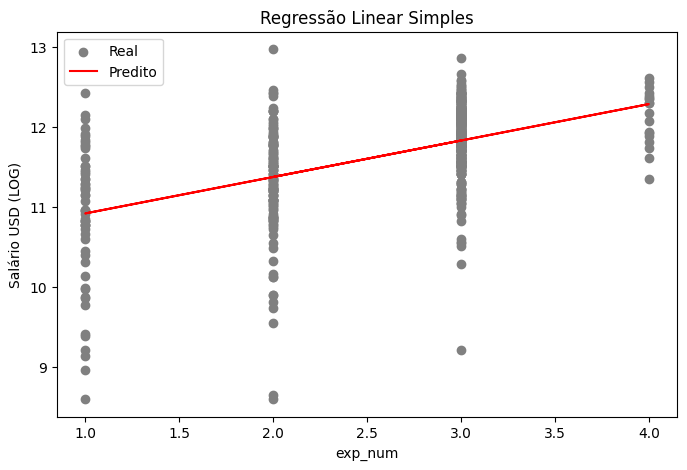

Desempenho do modelo (LinearRegression):
Erro Quadrático Médio (MSE): 0.320
Coeficiente de Determinação (R²): 0.279
--------------------------------------------------
Coeficientes da reta: intercecpto -> 10.463971442144642; coeficientes -> [0.45589202]


In [ ]:
# 1. Regressão Linear Simples
feature = 'exp_num'
X_train_simple = X_train[[feature]]
X_test_simple = X_test[[feature]]

lr_simple = LinearRegression()
lr_simple.fit(X_train_simple, y_train)
y_pred_simple = lr_simple.predict(X_test_simple)

plt.figure(figsize=(8, 5))
plt.scatter(X_test_simple, y_test, color='gray', label='Real')
plt.plot(X_test_simple, y_pred_simple, color='red', label='Predito')
plt.xlabel(feature)
plt.ylabel('Salário USD (LOG)')
plt.title('Regressão Linear Simples')
plt.legend()
plt.show()

# Chamando a função para imprimir as métricas
imprimir_metricas(lr_simple, X_test, y_test, y_pred_simple)
print(f"Coeficientes da reta: intercecpto -> {lr_simple.intercept_}; coeficientes -> {lr_simple.coef_}")

Enquanto a regressão linear simples considera apenas uma feature em relação à variável target, na regressão múltipla, consideramos várias features em uma tentativa de prever a target.

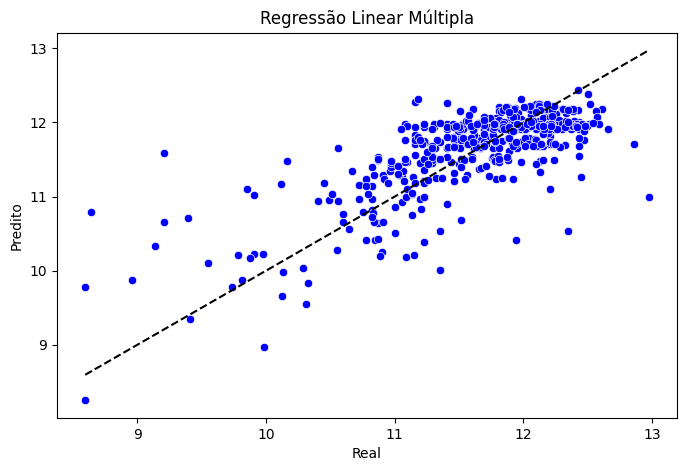

Desempenho do modelo (LinearRegression):
Erro Quadrático Médio (MSE): 0.201
Coeficiente de Determinação (R²): 0.548
--------------------------------------------------
Coeficientes da reta: intercecpto -> -63.227776583713954; coeficientes -> [ 3.62010663e-02 -2.29423733e-04  1.85238806e-01  9.55267740e-02
 -8.36964017e-02  4.04798985e-02  2.26338958e-02  2.05826073e-02
  2.57675530e-02  1.41207525e-01  3.90567359e-01 -5.57542437e-01
 -8.24784949e-01  6.53280484e-01 -3.07860562e-02 -2.08428343e-01
  1.85419258e-01  8.21211066e-02 -1.53340751e-01  8.04347274e-02
  2.98330119e-01 -1.25439597e+00 -1.21544641e-01  3.94335815e-01
 -1.50585477e-01 -6.81995328e-01 -1.10545890e-01  4.34140353e-01
 -6.69640604e-02 -2.05245053e-01  7.92036733e-02  5.00183379e-01
  7.36345508e-01 -6.47281316e-02 -5.90613125e-01  2.19586830e-01
  8.79867855e-01 -1.07889162e-01  1.33299690e-02  1.44534106e-01
  1.10663532e+00  1.22914803e-01 -3.62694018e-01  4.48447917e-02
 -8.73116725e-02 -2.06185003e-01  2.30669956

In [ ]:
# 2. Regressão Linear Múltipla
lr_multiple = LinearRegression()
lr_multiple.fit(X_train, y_train)
y_pred_multiple = lr_multiple.predict(X_test)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_multiple, color='blue')
plt.xlabel('Real')
plt.ylabel('Predito')
plt.title('Regressão Linear Múltipla')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.show()

imprimir_metricas(lr_multiple, X_test, y_test, y_pred_multiple)
print(f"Coeficientes da reta: intercecpto -> {lr_multiple.intercept_}; coeficientes -> {lr_multiple.coef_}")

Em seguida, usamos uma regressão polinomial simples, que utiliza apenas uma feature, mas em diferentes potências, não apresentando estritamente uma linha reta.

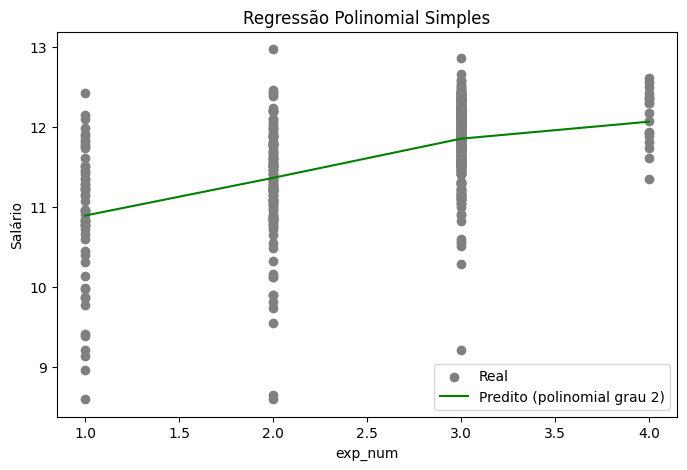

Desempenho do modelo (LinearRegression):
Erro Quadrático Médio (MSE): 0.319
Coeficiente de Determinação (R²): 0.283
--------------------------------------------------


In [ ]:
# 3. Regressão Polinomial Simples (Experiência)
poly_simple = PolynomialFeatures(degree=4, include_bias=False)
X_train_poly = poly_simple.fit_transform(X_train_simple)
X_test_poly = poly_simple.transform(X_test_simple)

lr_poly_simple = LinearRegression()
lr_poly_simple.fit(X_train_poly, y_train)
y_pred_poly_simple = lr_poly_simple.predict(X_test_poly)

# Ordenar para plotagem suave
sort_idx = np.argsort(X_test_simple.values.ravel())
X_sorted = X_test_simple.values.ravel()[sort_idx]
y_sorted = y_pred_poly_simple[sort_idx]

plt.figure(figsize=(8, 5))
plt.scatter(X_test_simple, y_test, color='gray', label='Real')
plt.plot(X_sorted, y_sorted, color='green', label='Predito (polinomial grau 2)')
plt.xlabel(feature)
plt.ylabel('Salário')
plt.title('Regressão Polinomial Simples')
plt.legend()
plt.show()
imprimir_metricas(lr_poly_simple, X_test, y_test, y_pred_poly_simple)

In [ ]:
# ESTA CÉLULA FOI COMENTADA PORQUE SUA EXECUÇÃO ORIGINALMENTE CAUSA UM ERRO DE MEMÓRIA (OUT OF MEMORY)
# Explicação:
# --------------------------------------------------------------------------------------------------------------------
# 1. Grande número de Features Originais: O dataset 'X' possui 264 features de entrada.
# 2. Explosão de Features com PolynomialFeatures: A transformação `PolynomialFeatures` cria novas features
#    que são combinações polinomiais das features existentes. Para um `degree` (grau) de 2 ou mais,
#    o número de features geradas cresce exponencialmente (combinatoriamente). Por exemplo:
#    - Para `degree=2`: O número de features geradas é aproximadamente (n_features^2)/2, mais as n_features originais.
#                     Com 264 features, isso significa cerca de (264^2)/2 = 34848 novas features, além das 264 originais.
#                     Isso resulta em um total de aproximadamente 35.000 features.
#    - Para `degree=3`: O número de features cresce ainda mais drasticamente, chegando a milhões de features.
# 3. Consumo Excessivo de Memória: Treinar um modelo linear (LinearRegression) com dezenas ou centenas de milhares
#    de features em 5 folds de validação cruzada (`cv=5`) exige uma quantidade de memória RAM que excede
#    as capacidades de ambientes como o Google Colab, levando ao erro `TerminatedWorkerError: SIGKILL(-9)`
#    (o sistema operacional encerra o processo por falta de memória).
# 4. GridSearchCV e Param_Grid: A configuração `param_grid = {'poly__degree': np.arange(1, 6)}` tenta testar
#    graus de 1 a 5. Mesmo o grau 2 já causa o erro de memória com tantas features de entrada.
#    O grau 1 é equivalente a uma regressão linear (o que foi demonstrado na célula 'cb0a5a2b' que funciona),
#    mas os graus superiores são inviáveis na configuração atual.
# --------------------------------------------------------------------------------------------------------------------

# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import GridSearchCV

# # 4. Regressão Polinomial Múltipla com GridSearchCV
# pipeline = Pipeline([
#     ('poly', PolynomialFeatures(include_bias=False)),
#     ('linear', LinearRegression())
# ])

# param_grid = {
#     'poly__degree': np.arange(1, 6) # Este range causa o erro de memória com 264 features
# }

# grid_search = GridSearchCV(
#     pipeline,
#     param_grid,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1  # Usa todos os núcleos da CPU para ir mais rápido!
# )
# grid_search.fit(X_train, y_train)

# # O modelo treinado de verdade está guardado aqui!
# melhor_modelo = grid_search.best_estimator_
# melhor_grau = grid_search.best_params_['poly__degree']
# print(f"Melhor grau encontrado: {melhor_grau}")

# y_pred_poly_multi = melhor_modelo.predict(X_test)

# plt.figure(figsize=(8, 5))
# sns.scatterplot(x=y_test, y=y_pred_poly_multi, color='purple')
# plt.xlabel('Real')
# plt.ylabel('Predito')
# plt.title('Regressão Polinomial Múltipla')
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
# plt.show()

# # Correção feita aqui: passando 'melhor_modelo' em vez de 'pipeline'
# imprimir_metricas(melhor_modelo, X_test, y_test, y_pred_poly_multi)

A célula anterior falhou devido a um erro de memória. `PolynomialFeatures` com um grau alto em muitas colunas pode criar um número gigantesco de novas features, consumindo toda a memória disponível.

Para tentar resolver isso, vamos **reduzir o grau máximo** testado na busca em grade para `2` ou `3`.

Melhor grau encontrado: 1


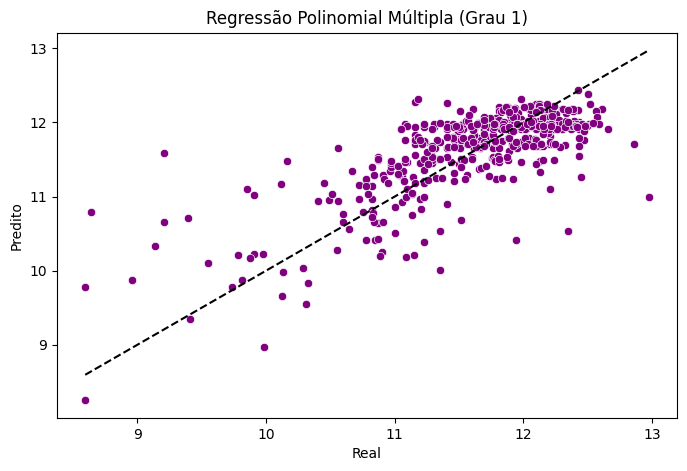

Desempenho do modelo (Pipeline):
Erro Quadrático Médio (MSE): 0.201
Coeficiente de Determinação (R²): 0.548
--------------------------------------------------


In [ ]:
# 4. Regressão Polinomial Múltipla com GridSearchCV
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('linear', LinearRegression())
])

param_grid = {
    'poly__degree': np.arange(1, 2) # Limitando para testar APENAS o grau 1 para evitar erro de RAM
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

# O modelo treinado de verdade está guardado aqui!
melhor_modelo = grid_search.best_estimator_
melhor_grau = grid_search.best_params_['poly__degree']
print(f"Melhor grau encontrado: {melhor_grau}")

y_pred_poly_multi = melhor_modelo.predict(X_test)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_poly_multi, color='purple')
plt.xlabel('Real')
plt.ylabel('Predito')
plt.title(f'Regressão Polinomial Múltipla (Grau {melhor_grau})')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.show()

imprimir_metricas(melhor_modelo, X_test, y_test, y_pred_poly_multi)

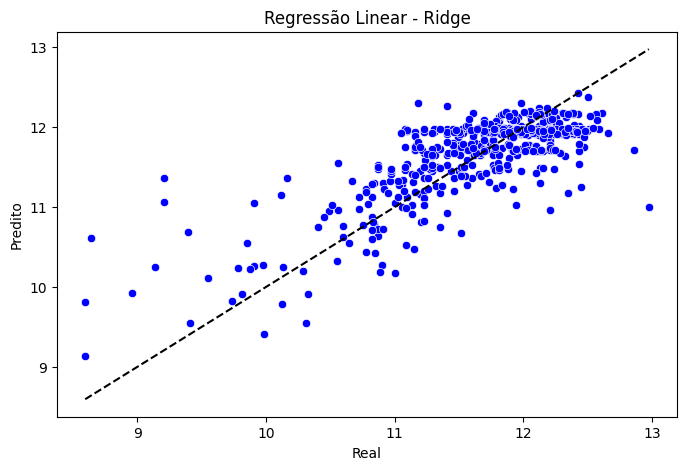

Desempenho do modelo (Ridge):
Erro Quadrático Médio (MSE): 0.178
Coeficiente de Determinação (R²): 0.598
--------------------------------------------------
Coeficientes da reta: intercecpto -> -69.27672055152975; coeficientes -> [ 3.92139481e-02 -1.89302445e-04  1.87944498e-01  8.44923842e-02
 -8.60251157e-02  3.73434362e-02  2.14491694e-02  2.72325101e-02
 -1.09282379e-01  1.17893688e-01  3.22939973e-01 -3.31551282e-01
 -2.63615315e-01  4.93182599e-01  1.01732610e-01 -1.32164300e-01
  1.94140018e-01  1.11103373e-01  5.30500453e-02  6.95083563e-02
  2.58247022e-01 -3.29728709e-01 -9.16058357e-03  2.78721881e-01
 -1.25190705e-01 -2.97073392e-01 -1.22331045e-01  1.92763601e-01
 -1.29273113e-01 -1.18567207e-01  4.24957254e-02  2.35365949e-01
  2.09836110e-01 -7.67342781e-02 -1.99029449e-01  1.71151894e-01
  3.05793913e-01 -8.38495079e-02  5.47925290e-02  8.53744616e-02
  3.78591605e-01  1.39624289e-01 -2.27636480e-01  1.84005883e-02
 -7.74224636e-02 -1.25394006e-01  8.99055396e-02  1.4655

In [ ]:
# 5. Regressão Linear Ridge
from sklearn.linear_model import Ridge

lr_ridge = Ridge()
lr_ridge.fit(X_train, y_train)
y_pred_ridge = lr_ridge.predict(X_test)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_ridge, color='blue')
plt.xlabel('Real')
plt.ylabel('Predito')
plt.title('Regressão Linear - Ridge')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.show()

imprimir_metricas(lr_ridge, X_test, y_test, y_pred_ridge)
print(f"Coeficientes da reta: intercecpto -> {lr_ridge.intercept_}; coeficientes -> {lr_ridge.coef_}")

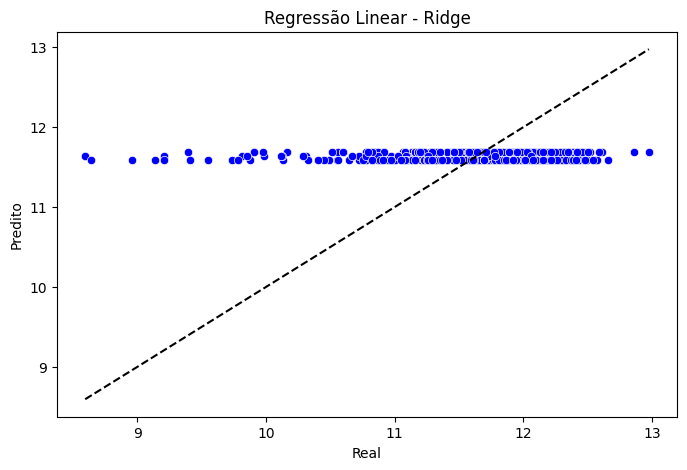

Desempenho do modelo (Ridge):
Erro Quadrático Médio (MSE): 0.443
Coeficiente de Determinação (R²): 0.004
--------------------------------------------------
Coeficientes da reta: intercecpto -> 11.688320182908134; coeficientes -> [ 0.        -0.0010191  0.        -0.        -0.         0.
 -0.         0.        -0.        -0.         0.        -0.
 -0.        -0.        -0.        -0.         0.        -0.
 -0.        -0.         0.        -0.        -0.        -0.
 -0.        -0.         0.         0.        -0.        -0.
  0.         0.        -0.         0.        -0.        -0.
 -0.        -0.        -0.        -0.        -0.         0.
 -0.         0.        -0.         0.         0.         0.
  0.        -0.        -0.        -0.        -0.        -0.
 -0.        -0.         0.         0.         0.        -0.
 -0.         0.         0.        -0.         0.         0.
  0.        -0.         0.         0.         0.         0.
 -0.        -0.        -0.         0.        -0.   

In [ ]:
# 6. Regressão Linear Lasso
from sklearn.linear_model import Lasso

lr_lasso = Lasso()
lr_lasso.fit(X_train, y_train)
y_pred_lasso = lr_lasso.predict(X_test)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_lasso, color='blue')
plt.xlabel('Real')
plt.ylabel('Predito')
plt.title('Regressão Linear - Ridge')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.show()

imprimir_metricas(lr_ridge, X_test, y_test, y_pred_lasso)
print(f"Coeficientes da reta: intercecpto -> {lr_lasso.intercept_}; coeficientes -> {lr_lasso.coef_}")

Melhor alpha encontrado para Lasso: 0.0008


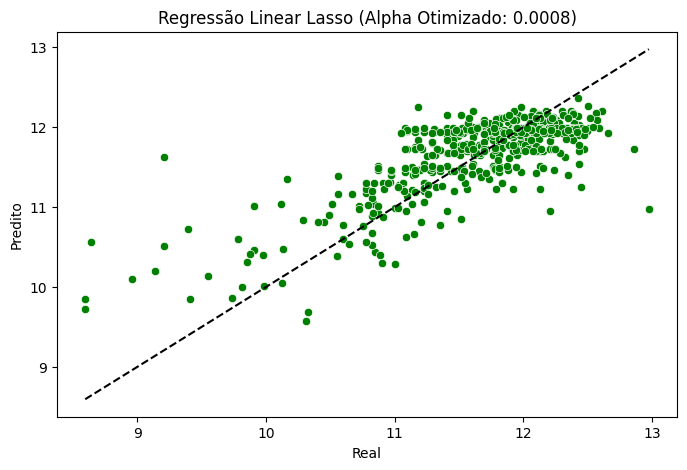

Desempenho do modelo (Pipeline):
Erro Quadrático Médio (MSE): 0.176
Coeficiente de Determinação (R²): 0.604
--------------------------------------------------
Coeficientes da reta: intercecpto -> -82.899; coeficientes -> [ 4.59718197e-02 -2.05441155e-04  2.12783233e-01  6.79182413e-02
 -7.42442110e-02 -0.00000000e+00  0.00000000e+00  0.00000000e+00
 -1.70272684e-03  0.00000000e+00  3.45517757e-01 -0.00000000e+00
 -0.00000000e+00  3.35723032e-01  0.00000000e+00 -0.00000000e+00
  1.66227381e-01  0.00000000e+00  0.00000000e+00 -0.00000000e+00
  1.65821756e-01 -0.00000000e+00  0.00000000e+00  0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00  0.00000000e+00
 -0.00000000e+00 -0.00000000e+00  0.00000000e+00  0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00  1.96405218e-02
  0.00000000e+00 -7.43229630e-02  0.00000000e+00 -0.00000000e+00
  0.00000000e+00  4.33821601e-02 -0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -6.12802504e-02  0.00000000e+00  0.00000000e+00

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# 6.2 Regressão Linear Lasso com otimização de Alpha

# Definir o pipeline (opcional, mas bom para consistência com outros modelos)
pipeline_lasso = Pipeline([
    ('lasso', Lasso())
])

# Definir a grade de parâmetros para 'alpha'
# É comum usar uma escala logarítmica para alpha no Lasso/Ridge
param_grid_lasso = {
    'lasso__alpha': np.logspace(-4, 0, 10) # Testar 10 valores de alpha de 0.0001 a 1.0
}

grid_search_lasso = GridSearchCV(
    pipeline_lasso,
    param_grid_lasso,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search_lasso.fit(X_train, y_train)

melhor_modelo_lasso = grid_search_lasso.best_estimator_
melhor_alpha_lasso = grid_search_lasso.best_params_['lasso__alpha']
print(f"Melhor alpha encontrado para Lasso: {melhor_alpha_lasso:.4f}")

y_pred_lasso_otimizado = melhor_modelo_lasso.predict(X_test)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_lasso_otimizado, color='green')
plt.xlabel('Real')
plt.ylabel('Predito')
plt.title(f'Regressão Linear Lasso (Alpha Otimizado: {melhor_alpha_lasso:.4f})')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.show()

imprimir_metricas(melhor_modelo_lasso, X_test, y_test, y_pred_lasso_otimizado)
print(f"Coeficientes da reta: intercecpto -> {melhor_modelo_lasso['lasso'].intercept_:.3f}; coeficientes -> {melhor_modelo_lasso['lasso'].coef_}")
